# Crypto Portfolio Risk Dashboard

This project builds a portfolio risk dashboard for a multi-asset crypto portfolio.

The dashboard analyses historical price data for major crypto assets and evaluates portfolio-level risk using returns, volatility, correlations, drawdowns, Value at Risk, Expected Shortfall and risk contribution.

The aim is to understand not only which assets performed best historically, but which assets contributed most to portfolio risk.

This project is for educational and research purposes only. It is not financial advice, investment advice or a recommendation to buy or sell any crypto asset.

In [1]:
!pip install yfinance --quiet

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Portfolio Setup

The dashboard tests a crypto portfolio across several major assets. The portfolio weights can be changed to test different allocation assumptions.

The initial allocation is not a recommendation. It is used only as a sample portfolio for risk analysis.

In [3]:
assets = {
    "BTC": "BTC-USD",
    "ETH": "ETH-USD",
    "SOL": "SOL-USD",
    "BNB": "BNB-USD",
    "XRP": "XRP-USD",
    "ADA": "ADA-USD",
    "LINK": "LINK-USD"
}

portfolio_weights = {
    "BTC": 0.40,
    "ETH": 0.25,
    "SOL": 0.15,
    "BNB": 0.10,
    "XRP": 0.04,
    "ADA": 0.03,
    "LINK": 0.03
}

start_date = "2020-01-01"
initial_portfolio_value = 10000
trading_days = 365

In [4]:
total_weight = sum(portfolio_weights.values())

if round(total_weight, 6) != 1:
    raise ValueError(f"Portfolio weights must sum to 1. Current total: {total_weight}")

portfolio_weights

{'BTC': 0.4,
 'ETH': 0.25,
 'SOL': 0.15,
 'BNB': 0.1,
 'XRP': 0.04,
 'ADA': 0.03,
 'LINK': 0.03}

## Data Download And Cleaning

Daily price data is downloaded using `yfinance`. The dashboard uses adjusted close prices where available and aligns all assets into a single price table.

Rows with missing prices are removed so that portfolio-level calculations use a consistent sample across all assets.


In [5]:
def download_crypto_prices(assets, start_date):
    price_data = pd.DataFrame()

    for asset_name, ticker in assets.items():
        data = yf.download(ticker, start=start_date, progress=False, auto_adjust=True)

        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)

        if "Adj Close" in data.columns:
            price_data[asset_name] = data["Adj Close"]
        else:
            price_data[asset_name] = data["Close"]

    price_data = price_data.dropna()

    return price_data

In [6]:
prices = download_crypto_prices(assets, start_date)

prices.head()

,BTC,ETH,SOL,BNB,XRP,ADA,LINK
Date,,,,,,,
2020-04-10,6865.493164,158.412445,0.951054,13.737724,0.187464,0.033215,3.217100
2020-04-11,6859.083008,158.216019,0.776819,13.804288,0.188063,0.033354,3.282313
2020-04-12,6971.091797,161.142426,0.882507,14.375111,0.190135,0.033806,3.462612
2020-04-13,6845.037598,156.279556,0.777832,15.034427,0.187732,0.033107,3.369805
2020-04-14,6842.427734,157.596390,0.661925,15.525076,0.185335,0.032974,3.236892


In [7]:
prices.tail()

,BTC,ETH,SOL,BNB,XRP,ADA,LINK
Date,,,,,,,
2026-06-10,61449.289062,1620.137695,63.160954,586.173828,1.097237,0.160767,7.562988
2026-06-11,63561.054688,1672.280640,66.822006,605.041565,1.141586,0.170336,7.882299
2026-06-12,63543.199219,1665.127808,66.749275,603.506592,1.132059,0.169840,7.855693
2026-06-13,64421.324219,1680.214600,68.872787,609.543762,1.150045,0.171751,7.977420
2026-06-14,65393.070312,1721.229980,70.389999,614.119995,1.171800,0.175400,8.103000


In [8]:
daily_returns = prices.pct_change().dropna()

daily_returns.head()

,BTC,ETH,SOL,BNB,XRP,ADA,LINK
Date,,,,,,,
2020-04-11,-0.000934,-0.001240,-0.183202,0.004845,0.003195,0.004185,0.020271
2020-04-12,0.016330,0.018496,0.136052,0.041351,0.011018,0.013552,0.054930
2020-04-13,-0.018082,-0.030177,-0.118611,0.045865,-0.012638,-0.020677,-0.026803
2020-04-14,-0.000381,0.008426,-0.149013,0.032635,-0.012768,-0.004017,-0.039442
2020-04-15,-0.029276,-0.027345,-0.023075,-0.059977,-0.021933,-0.033693,-0.033327


In [9]:
daily_returns.describe().round(4)

,BTC,ETH,SOL,BNB,XRP,ADA,LINK
count,2256.0000,2256.0000,2256.0000,2256.0000,2256.0000,2256.0000,2256.0000
mean,0.0015,0.0019,0.0039,0.0025,0.0022,0.0020,0.0018
std,0.0302,0.0407,0.0627,0.0423,0.0540,0.0515,0.0530
min,-0.1597,-0.2720,-0.4228,-0.3327,-0.4233,-0.2601,-0.3724
25%,-0.0128,-0.0179,-0.0300,-0.0146,-0.0197,-0.0246,-0.0274
50%,0.0004,0.0009,-0.0006,0.0013,-0.0001,-0.0008,0.0009
75%,0.0149,0.0207,0.0321,0.0179,0.0189,0.0231,0.0284
max,0.1875,0.2595,0.4728,0.6976,0.7308,0.7133,0.3283


In [10]:
weights = pd.Series(portfolio_weights)

portfolio_daily_returns = daily_returns.dot(weights)

portfolio_value = initial_portfolio_value * (1 + portfolio_daily_returns).cumprod()

portfolio_summary = pd.DataFrame({
    "Portfolio Daily Return": portfolio_daily_returns,
    "Portfolio Value": portfolio_value
})

portfolio_summary.head()

,Portfolio Daily Return,Portfolio Value
Date,,
2020-04-11,-0.026818,9731.822478
2020-04-12,0.038194,10103.521589
2020-04-13,-0.029912,9801.301113
2020-04-14,-0.018949,9615.577082
2020-04-15,-0.030894,9318.517865


In [11]:
portfolio_summary.tail()

,Portfolio Daily Return,Portfolio Value
Date,,
2026-06-10,-0.012502,263768.390929
2026-06-11,0.038375,273890.455502
2026-06-12,-0.002121,273309.510188
2026-06-13,0.015003,277410.004946
2026-06-14,0.018058,282419.428388


## Portfolio Performance Summary

This section calculates the main performance and risk metrics for the sample crypto portfolio.

The dashboard measures total return, annualised return, annualised volatility, Sharpe ratio, best and worst daily return, maximum drawdown, Value at Risk and Expected Shortfall.

These metrics help assess whether the portfolio’s historical return was achieved with acceptable levels of risk.

In [12]:
def calculate_drawdown(return_series):
    cumulative_value = initial_portfolio_value * (1 + return_series).cumprod()
    running_peak = cumulative_value.cummax()
    drawdown = cumulative_value / running_peak - 1

    return drawdown

In [13]:
portfolio_drawdown = calculate_drawdown(portfolio_daily_returns)

sample_start = portfolio_summary.index[0]
sample_end = portfolio_summary.index[-1]
sample_days = (sample_end - sample_start).days

final_portfolio_value = portfolio_summary["Portfolio Value"].iloc[-1]
total_return = final_portfolio_value / initial_portfolio_value - 1
annualised_return = (final_portfolio_value / initial_portfolio_value) ** (trading_days / sample_days) - 1
annualised_volatility = portfolio_daily_returns.std() * np.sqrt(trading_days)
sharpe_ratio = annualised_return / annualised_volatility

best_day = portfolio_daily_returns.max()
worst_day = portfolio_daily_returns.min()
maximum_drawdown = portfolio_drawdown.min()

var_95 = portfolio_daily_returns.quantile(0.05)
expected_shortfall_95 = portfolio_daily_returns[portfolio_daily_returns <= var_95].mean()

var_99 = portfolio_daily_returns.quantile(0.01)
expected_shortfall_99 = portfolio_daily_returns[portfolio_daily_returns <= var_99].mean()

performance_summary = pd.DataFrame({
    "Metric": [
        "Start Date",
        "End Date",
        "Sample Days",
        "Initial Portfolio Value",
        "Final Portfolio Value",
        "Total Return",
        "Annualised Return",
        "Annualised Volatility",
        "Sharpe Ratio",
        "Best Daily Return",
        "Worst Daily Return",
        "Maximum Drawdown",
        "Daily 95% Value At Risk",
        "Daily 95% Expected Shortfall",
        "Daily 99% Value At Risk",
        "Daily 99% Expected Shortfall"
    ],
    "Value": [
        sample_start.date(),
        sample_end.date(),
        sample_days,
        initial_portfolio_value,
        final_portfolio_value,
        total_return,
        annualised_return,
        annualised_volatility,
        sharpe_ratio,
        best_day,
        worst_day,
        maximum_drawdown,
        var_95,
        expected_shortfall_95,
        var_99,
        expected_shortfall_99
    ]
})

performance_summary

,Metric,Value
0,Start Date,2020-04-11
1,End Date,2026-06-14
2,Sample Days,2255
3,Initial Portfolio Value,10000
4,Final Portfolio Value,282419.428388
5,Total Return,27.241943
6,Annualised Return,0.717297
7,Annualised Volatility,0.662549
8,Sharpe Ratio,1.082632
9,Best Daily Return,0.204375


In [14]:
performance_summary_display = performance_summary.copy()

percentage_metrics = [
    "Total Return",
    "Annualised Return",
    "Annualised Volatility",
    "Best Daily Return",
    "Worst Daily Return",
    "Maximum Drawdown",
    "Daily 95% Value At Risk",
    "Daily 95% Expected Shortfall",
    "Daily 99% Value At Risk",
    "Daily 99% Expected Shortfall"
]

currency_metrics = [
    "Initial Portfolio Value",
    "Final Portfolio Value"
]

for index, row in performance_summary_display.iterrows():
    metric = row["Metric"]
    value = row["Value"]

    if metric in percentage_metrics:
        performance_summary_display.loc[index, "Value"] = f"{value * 100:.2f}%"
    elif metric in currency_metrics:
        performance_summary_display.loc[index, "Value"] = f"£{value:,.2f}"
    elif metric == "Sharpe Ratio":
        performance_summary_display.loc[index, "Value"] = f"{value:.2f}"

performance_summary_display

,Metric,Value
0,Start Date,2020-04-11
1,End Date,2026-06-14
2,Sample Days,2255
3,Initial Portfolio Value,"£10,000.00"
4,Final Portfolio Value,"£282,419.43"
5,Total Return,2724.19%
6,Annualised Return,71.73%
7,Annualised Volatility,66.25%
8,Sharpe Ratio,1.08
9,Best Daily Return,20.44%


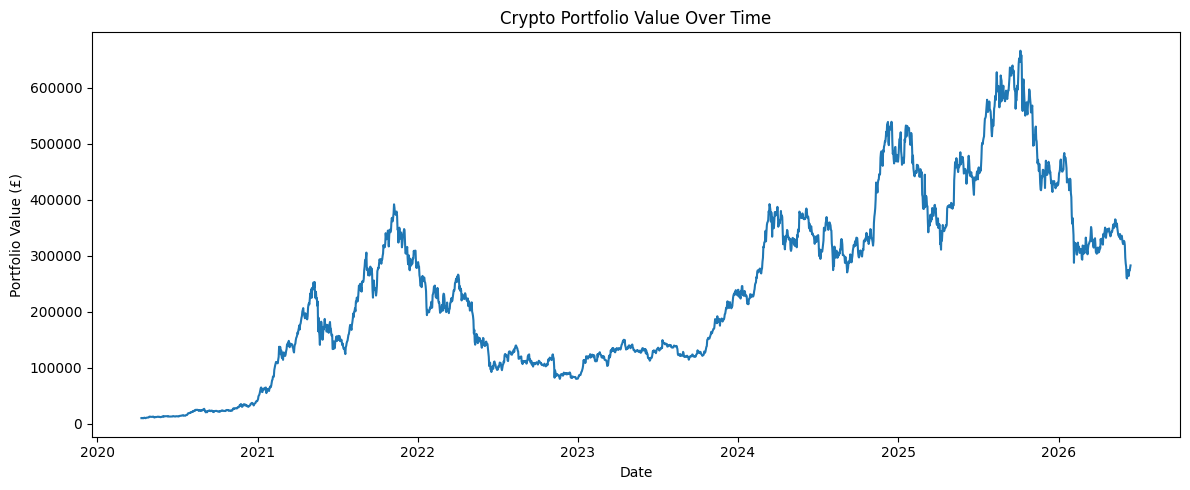

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(portfolio_summary.index, portfolio_summary["Portfolio Value"])

plt.title("Crypto Portfolio Value Over Time")
plt.ylabel("Portfolio Value (£)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

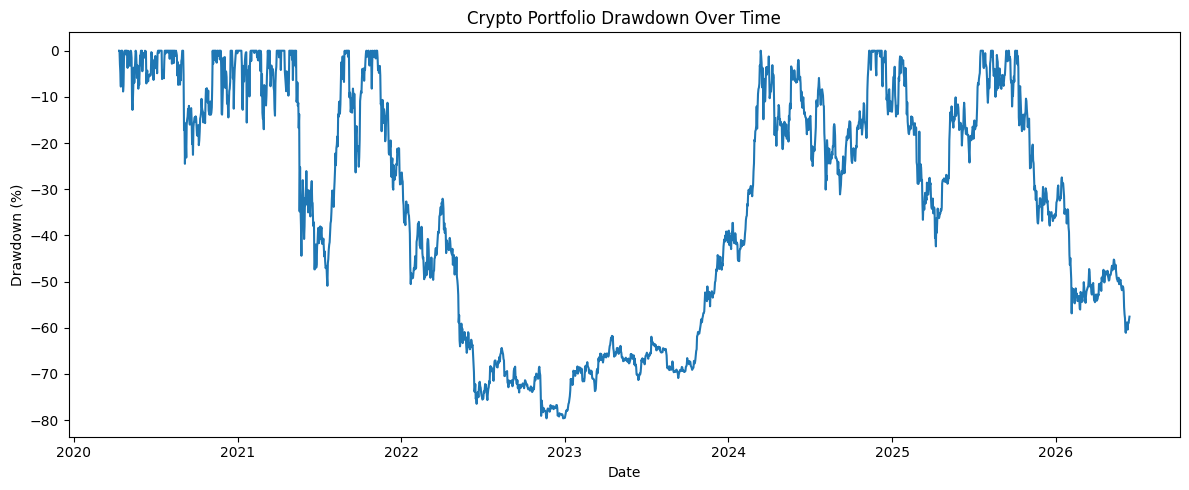

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(portfolio_drawdown.index, portfolio_drawdown * 100)

plt.title("Crypto Portfolio Drawdown Over Time")
plt.ylabel("Drawdown (%)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

## Asset-Level Risk Summary

Portfolio-level returns can hide the risk of individual assets. This section compares each asset by total return, annualised volatility, maximum drawdown, Value at Risk and Expected Shortfall.

This helps identify which assets contributed strong returns, which assets carried the highest standalone risk, and which assets experienced the deepest historical losses.

In [17]:
asset_risk_results = []

for asset in daily_returns.columns:
    asset_returns = daily_returns[asset]
    asset_value = initial_portfolio_value * (1 + asset_returns).cumprod()
    asset_drawdown = asset_value / asset_value.cummax() - 1

    final_value = asset_value.iloc[-1]
    total_return = final_value / initial_portfolio_value - 1
    annualised_return = (final_value / initial_portfolio_value) ** (trading_days / sample_days) - 1
    annualised_volatility = asset_returns.std() * np.sqrt(trading_days)
    maximum_drawdown = asset_drawdown.min()
    best_day = asset_returns.max()
    worst_day = asset_returns.min()

    var_95 = asset_returns.quantile(0.05)
    expected_shortfall_95 = asset_returns[asset_returns <= var_95].mean()

    asset_risk_results.append({
        "Asset": asset,
        "Total Return": total_return,
        "Annualised Return": annualised_return,
        "Annualised Volatility": annualised_volatility,
        "Best Daily Return": best_day,
        "Worst Daily Return": worst_day,
        "Maximum Drawdown": maximum_drawdown,
        "Daily 95% Value At Risk": var_95,
        "Daily 95% Expected Shortfall": expected_shortfall_95
    })

asset_risk_summary = pd.DataFrame(asset_risk_results)

In [18]:
asset_risk_summary_display = asset_risk_summary.copy()

asset_percentage_columns = [
    "Total Return",
    "Annualised Return",
    "Annualised Volatility",
    "Best Daily Return",
    "Worst Daily Return",
    "Maximum Drawdown",
    "Daily 95% Value At Risk",
    "Daily 95% Expected Shortfall"
]

for column in asset_percentage_columns:
    asset_risk_summary_display[column] = asset_risk_summary_display[column] * 100

asset_risk_summary_display = asset_risk_summary_display.round(2)

asset_risk_summary_display.sort_values(
    by="Annualised Volatility",
    ascending=False
)

,Asset,Total Return,Annualised Return,Annualised Volatility,Best Daily Return,Worst Daily Return,Maximum Drawdown,Daily 95% Value At Risk,Daily 95% Expected Shortfall
2,SOL,7301.26,100.71,119.83,47.28,-42.28,-96.27,-8.40,-12.60
4,XRP,525.08,34.53,103.11,73.08,-42.33,-83.25,-6.47,-10.54
6,LINK,151.87,16.13,101.25,32.83,-37.24,-90.19,-7.84,-11.42
5,ADA,428.07,30.91,98.45,71.33,-26.01,-94.72,-7.13,-10.18
3,BNB,4370.32,84.98,80.88,69.76,-33.27,-70.84,-5.67,-8.73
1,ETH,986.55,47.13,77.68,25.95,-27.20,-79.35,-6.10,-9.07
0,BTC,852.49,44.03,57.65,18.75,-15.97,-76.63,-4.58,-6.83


## Correlation Analysis

Correlation measures how closely assets move together. In portfolio risk management, this matters because diversification benefits are weaker when assets are highly correlated.

This section calculates the daily return correlation between the selected crypto assets.

In [19]:
correlation_matrix = daily_returns.corr()

correlation_matrix.round(2)

,BTC,ETH,SOL,BNB,XRP,ADA,LINK
BTC,1.00,0.80,0.55,0.63,0.55,0.65,0.66
ETH,0.80,1.00,0.61,0.65,0.58,0.70,0.75
SOL,0.55,0.61,1.00,0.52,0.46,0.55,0.57
BNB,0.63,0.65,0.52,1.00,0.48,0.55,0.59
XRP,0.55,0.58,0.46,0.48,1.00,0.61,0.57
ADA,0.65,0.70,0.55,0.55,0.61,1.00,0.69
LINK,0.66,0.75,0.57,0.59,0.57,0.69,1.00


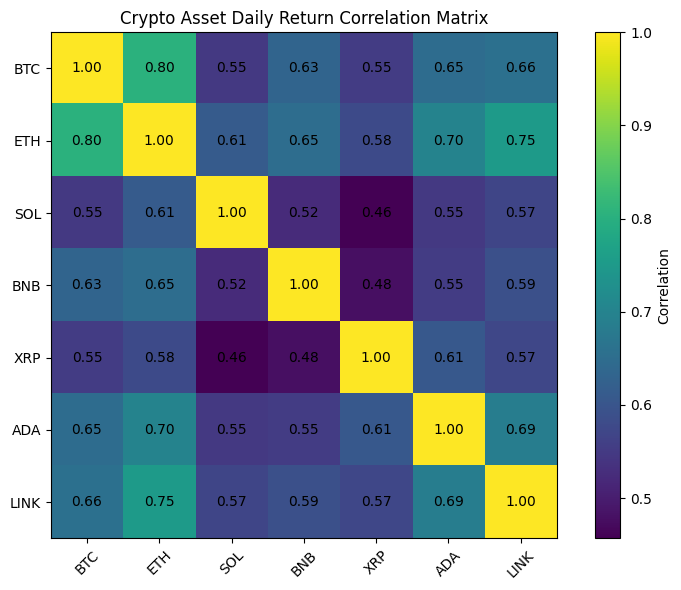

In [20]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix)
plt.colorbar(label="Correlation")

plt.xticks(
    ticks=range(len(correlation_matrix.columns)),
    labels=correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    ticks=range(len(correlation_matrix.index)),
    labels=correlation_matrix.index
)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Crypto Asset Daily Return Correlation Matrix")
plt.tight_layout()
plt.show()

## Rolling Volatility

Crypto portfolio risk changes significantly over time. A single volatility number does not show whether the portfolio became more or less risky during different market regimes.

This section calculates rolling 30-day annualised volatility for the portfolio.

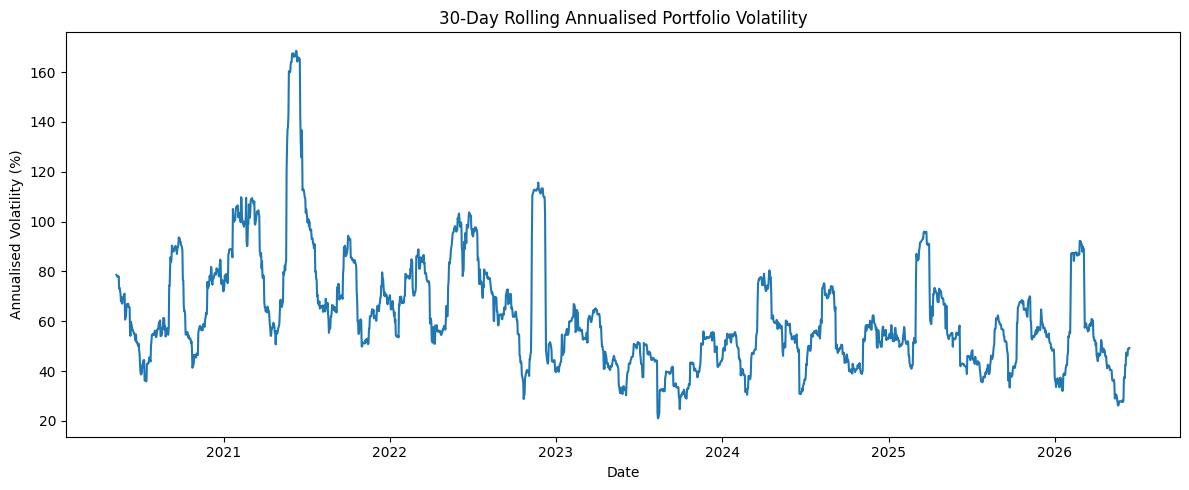

In [21]:
rolling_30d_volatility = portfolio_daily_returns.rolling(window=30).std() * np.sqrt(trading_days)

plt.figure(figsize=(12, 5))

plt.plot(rolling_30d_volatility.index, rolling_30d_volatility * 100)

plt.title("30-Day Rolling Annualised Portfolio Volatility")
plt.ylabel("Annualised Volatility (%)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

## Risk Contribution By Asset

Portfolio weights do not always reflect portfolio risk. An asset with a small allocation can still contribute heavily to overall portfolio volatility if it is highly volatile or highly correlated with the rest of the portfolio.

This section estimates each asset’s contribution to total portfolio volatility. This helps identify whether the portfolio is genuinely balanced or whether risk is concentrated in a small number of high-volatility assets.

In [22]:
annualised_covariance_matrix = daily_returns.cov() * trading_days

portfolio_variance = weights.T @ annualised_covariance_matrix @ weights
portfolio_volatility = np.sqrt(portfolio_variance)

marginal_risk_contribution = annualised_covariance_matrix @ weights / portfolio_volatility
component_risk_contribution = weights * marginal_risk_contribution
percentage_risk_contribution = component_risk_contribution / portfolio_volatility

risk_contribution_summary = pd.DataFrame({
    "Asset": weights.index,
    "Portfolio Weight": weights.values,
    "Marginal Risk Contribution": marginal_risk_contribution.values,
    "Volatility Contribution": component_risk_contribution.values,
    "Risk Contribution": percentage_risk_contribution.values
})

risk_contribution_summary

,Asset,Portfolio Weight,Marginal Risk Contribution,Volatility Contribution,Risk Contribution
0,BTC,0.40,0.520283,0.208113,0.314110
1,ETH,0.25,0.715094,0.178773,0.269827
2,SOL,0.15,0.939292,0.140894,0.212654
3,BNB,0.10,0.611412,0.061141,0.092282
4,XRP,0.04,0.680961,0.027238,0.041112
5,ADA,0.03,0.748625,0.022459,0.033897
6,LINK,0.03,0.797683,0.023931,0.036119


In [23]:
risk_contribution_display = risk_contribution_summary.copy()

risk_contribution_display["Portfolio Weight"] = risk_contribution_display["Portfolio Weight"] * 100
risk_contribution_display["Marginal Risk Contribution"] = risk_contribution_display["Marginal Risk Contribution"] * 100
risk_contribution_display["Volatility Contribution"] = risk_contribution_display["Volatility Contribution"] * 100
risk_contribution_display["Risk Contribution"] = risk_contribution_display["Risk Contribution"] * 100

risk_contribution_display = risk_contribution_display.round(2)

risk_contribution_display.sort_values(
    by="Risk Contribution",
    ascending=False
)

,Asset,Portfolio Weight,Marginal Risk Contribution,Volatility Contribution,Risk Contribution
0,BTC,40.0,52.03,20.81,31.41
1,ETH,25.0,71.51,17.88,26.98
2,SOL,15.0,93.93,14.09,21.27
3,BNB,10.0,61.14,6.11,9.23
4,XRP,4.0,68.10,2.72,4.11
6,LINK,3.0,79.77,2.39,3.61
5,ADA,3.0,74.86,2.25,3.39


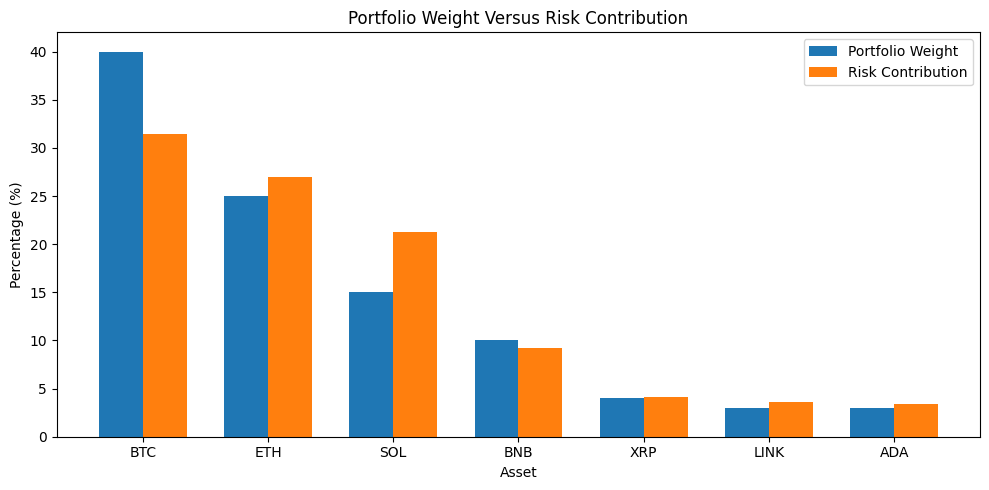

In [24]:
risk_chart_data = risk_contribution_display.sort_values(
    by="Risk Contribution",
    ascending=False
)

x = np.arange(len(risk_chart_data["Asset"]))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    risk_chart_data["Portfolio Weight"],
    width,
    label="Portfolio Weight"
)

plt.bar(
    x + width / 2,
    risk_chart_data["Risk Contribution"],
    width,
    label="Risk Contribution"
)

plt.xticks(x, risk_chart_data["Asset"])
plt.title("Portfolio Weight Versus Risk Contribution")
plt.ylabel("Percentage (%)")
plt.xlabel("Asset")
plt.legend()
plt.tight_layout()
plt.show()

## Portfolio Stress Testing

Historical risk metrics are useful, but they do not show how the portfolio could behave under specific market shock scenarios.

This section applies several hypothetical stress scenarios to the portfolio. Each scenario assumes different percentage losses across BTC, ETH and altcoins, then estimates the overall portfolio impact based on the current portfolio weights.

These stress tests are not predictions. They are used to understand downside exposure under simplified market conditions.

In [25]:
stress_scenarios = {
    "Broad 20% Market Sell-Off": {
        "BTC": -0.20,
        "ETH": -0.20,
        "SOL": -0.20,
        "BNB": -0.20,
        "XRP": -0.20,
        "ADA": -0.20,
        "LINK": -0.20
    },
    "Major Crypto Crash": {
        "BTC": -0.30,
        "ETH": -0.35,
        "SOL": -0.45,
        "BNB": -0.35,
        "XRP": -0.40,
        "ADA": -0.45,
        "LINK": -0.45
    },
    "Altcoin-Led Sell-Off": {
        "BTC": -0.10,
        "ETH": -0.15,
        "SOL": -0.40,
        "BNB": -0.30,
        "XRP": -0.35,
        "ADA": -0.40,
        "LINK": -0.40
    },
    "SOL-Specific Shock": {
        "BTC": -0.05,
        "ETH": -0.08,
        "SOL": -0.50,
        "BNB": -0.10,
        "XRP": -0.10,
        "ADA": -0.15,
        "LINK": -0.15
    },
    "Severe Bear Market Scenario": {
        "BTC": -0.60,
        "ETH": -0.70,
        "SOL": -0.85,
        "BNB": -0.65,
        "XRP": -0.60,
        "ADA": -0.75,
        "LINK": -0.75
    }
}

stress_results = []

for scenario_name, shocks in stress_scenarios.items():
    scenario_return = 0

    for asset, shock_return in shocks.items():
        scenario_return += portfolio_weights[asset] * shock_return

    stressed_portfolio_value = initial_portfolio_value * (1 + scenario_return)
    loss_amount = initial_portfolio_value - stressed_portfolio_value

    stress_results.append({
        "Scenario": scenario_name,
        "Portfolio Return": scenario_return,
        "Stressed Portfolio Value": stressed_portfolio_value,
        "Estimated Loss": loss_amount
    })

stress_test_summary = pd.DataFrame(stress_results)

stress_test_summary

,Scenario,Portfolio Return,Stressed Portfolio Value,Estimated Loss
0,Broad 20% Market Sell-Off,-0.2000,8000.0,2000.0
1,Major Crypto Crash,-0.3530,6470.0,3530.0
2,Altcoin-Led Sell-Off,-0.2055,7945.0,2055.0
3,SOL-Specific Shock,-0.1380,8620.0,1380.0
4,Severe Bear Market Scenario,-0.6765,3235.0,6765.0


In [26]:
stress_test_display = stress_test_summary.copy()

stress_test_display["Portfolio Return"] = stress_test_display["Portfolio Return"] * 100

stress_test_display["Stressed Portfolio Value"] = stress_test_display["Stressed Portfolio Value"].apply(
    lambda x: f"£{x:,.2f}"
)

stress_test_display["Estimated Loss"] = stress_test_display["Estimated Loss"].apply(
    lambda x: f"£{x:,.2f}"
)

stress_test_display["Portfolio Return"] = stress_test_display["Portfolio Return"].apply(
    lambda x: f"{x:.2f}%"
)

stress_test_display

,Scenario,Portfolio Return,Stressed Portfolio Value,Estimated Loss
0,Broad 20% Market Sell-Off,-20.00%,"£8,000.00","£2,000.00"
1,Major Crypto Crash,-35.30%,"£6,470.00","£3,530.00"
2,Altcoin-Led Sell-Off,-20.55%,"£7,945.00","£2,055.00"
3,SOL-Specific Shock,-13.80%,"£8,620.00","£1,380.00"
4,Severe Bear Market Scenario,-67.65%,"£3,235.00","£6,765.00"


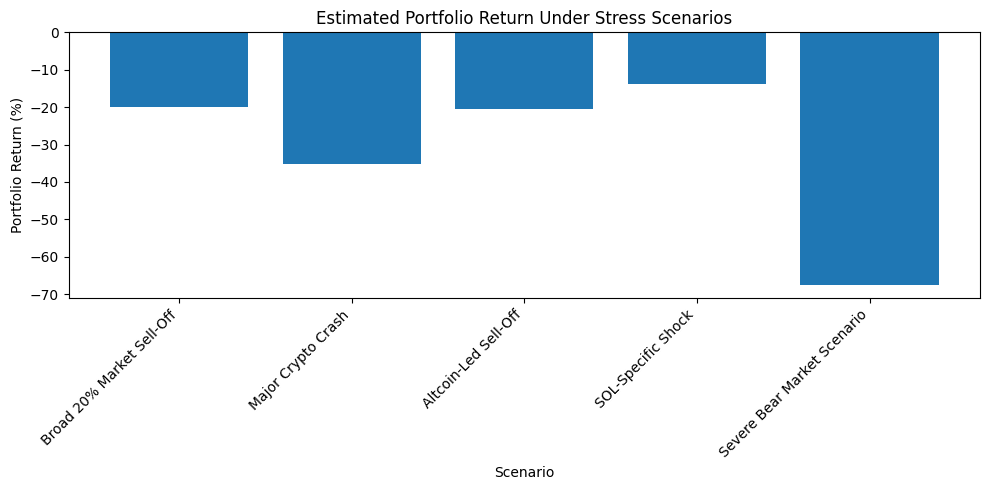

In [27]:
stress_chart_data = stress_test_summary.copy()

plt.figure(figsize=(10, 5))

plt.bar(
    stress_chart_data["Scenario"],
    stress_chart_data["Portfolio Return"] * 100
)

plt.title("Estimated Portfolio Return Under Stress Scenarios")
plt.ylabel("Portfolio Return (%)")
plt.xlabel("Scenario")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Stress Testing Findings

The stress tests show that the portfolio is highly exposed to broad crypto market drawdowns. A general 20% market sell-off would reduce the portfolio by 20%, while a more severe bear market scenario would reduce the portfolio by more than 65%.

The SOL-specific shock has a smaller portfolio-level impact because SOL represents 15% of the sample allocation. However, broader sell-off scenarios are much more damaging because BTC, ETH and altcoins are all assumed to fall at the same time.

This highlights an important portfolio risk point: although the portfolio contains several assets, diversification benefits may weaken during crypto market stress because the assets are positively correlated.

## Allocation Scenario Comparison

A portfolio risk dashboard becomes more useful when it can compare different allocation choices.

This section compares the sample portfolio against alternative allocation scenarios, including an equal-weight portfolio, a BTC/ETH core allocation and a higher-beta altcoin tilt.

The aim is to understand how changing portfolio weights affects return, volatility, drawdown and risk-adjusted performance.

In [28]:
allocation_scenarios = {
    "Sample Portfolio": portfolio_weights,
    "Equal Weight": {
        "BTC": 1 / 7,
        "ETH": 1 / 7,
        "SOL": 1 / 7,
        "BNB": 1 / 7,
        "XRP": 1 / 7,
        "ADA": 1 / 7,
        "LINK": 1 / 7
    },
    "BTC/ETH Core": {
        "BTC": 0.55,
        "ETH": 0.30,
        "SOL": 0.05,
        "BNB": 0.05,
        "XRP": 0.02,
        "ADA": 0.015,
        "LINK": 0.015
    },
    "Balanced Core-Satellite": {
        "BTC": 0.35,
        "ETH": 0.25,
        "SOL": 0.15,
        "BNB": 0.10,
        "XRP": 0.05,
        "ADA": 0.05,
        "LINK": 0.05
    },
    "High-Beta Altcoin Tilt": {
        "BTC": 0.25,
        "ETH": 0.20,
        "SOL": 0.25,
        "BNB": 0.10,
        "XRP": 0.08,
        "ADA": 0.06,
        "LINK": 0.06
    }
}

In [29]:
def calculate_allocation_metrics(allocation_name, allocation_weights):
    scenario_weights = pd.Series(allocation_weights).reindex(daily_returns.columns)

    if round(scenario_weights.sum(), 6) != 1:
        raise ValueError(f"{allocation_name} weights must sum to 1.")

    scenario_returns = daily_returns.dot(scenario_weights)
    scenario_value = initial_portfolio_value * (1 + scenario_returns).cumprod()
    scenario_drawdown = scenario_value / scenario_value.cummax() - 1

    final_value = scenario_value.iloc[-1]
    total_return = final_value / initial_portfolio_value - 1
    annualised_return = (final_value / initial_portfolio_value) ** (trading_days / sample_days) - 1
    annualised_volatility = scenario_returns.std() * np.sqrt(trading_days)
    sharpe_ratio = annualised_return / annualised_volatility
    maximum_drawdown = scenario_drawdown.min()

    var_95 = scenario_returns.quantile(0.05)
    expected_shortfall_95 = scenario_returns[scenario_returns <= var_95].mean()

    return {
        "Allocation": allocation_name,
        "Final Portfolio Value": final_value,
        "Total Return": total_return,
        "Annualised Return": annualised_return,
        "Annualised Volatility": annualised_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": maximum_drawdown,
        "Daily 95% Value At Risk": var_95,
        "Daily 95% Expected Shortfall": expected_shortfall_95
    }

In [30]:
allocation_results = []

for allocation_name, allocation_weights in allocation_scenarios.items():
    allocation_results.append(
        calculate_allocation_metrics(allocation_name, allocation_weights)
    )

allocation_comparison = pd.DataFrame(allocation_results)

allocation_comparison

,Allocation,Final Portfolio Value,Total Return,Annualised Return,Annualised Volatility,Sharpe Ratio,Maximum Drawdown,Daily 95% Value At Risk,Daily 95% Expected Shortfall
0,Sample Portfolio,282419.428388,27.241943,0.717297,0.662549,1.082632,-0.796126,-0.053844,-0.079768
1,Equal Weight,292311.808623,28.231181,0.726894,0.738238,0.984633,-0.809403,-0.057448,-0.088533
2,BTC/ETH Core,166919.958617,15.691996,0.577169,0.624783,0.923792,-0.771773,-0.050886,-0.075478
3,Balanced Core-Satellite,284062.169619,27.406217,0.718910,0.674863,1.065268,-0.799326,-0.054278,-0.081294
4,High-Beta Altcoin Tilt,400074.942072,39.007494,0.816882,0.725365,1.126166,-0.831822,-0.056347,-0.086131


In [31]:
allocation_comparison_display = allocation_comparison.copy()

allocation_percentage_columns = [
    "Total Return",
    "Annualised Return",
    "Annualised Volatility",
    "Maximum Drawdown",
    "Daily 95% Value At Risk",
    "Daily 95% Expected Shortfall"
]

for column in allocation_percentage_columns:
    allocation_comparison_display[column] = allocation_comparison_display[column] * 100

allocation_comparison_display["Final Portfolio Value"] = allocation_comparison_display[
    "Final Portfolio Value"
].apply(lambda x: f"£{x:,.2f}")

for column in allocation_percentage_columns:
    allocation_comparison_display[column] = allocation_comparison_display[column].apply(
        lambda x: f"{x:.2f}%"
    )

allocation_comparison_display["Sharpe Ratio"] = allocation_comparison_display[
    "Sharpe Ratio"
].apply(lambda x: f"{x:.2f}")

allocation_comparison_display

,Allocation,Final Portfolio Value,Total Return,Annualised Return,Annualised Volatility,Sharpe Ratio,Maximum Drawdown,Daily 95% Value At Risk,Daily 95% Expected Shortfall
0,Sample Portfolio,"£282,419.43",2724.19%,71.73%,66.25%,1.08,-79.61%,-5.38%,-7.98%
1,Equal Weight,"£292,311.81",2823.12%,72.69%,73.82%,0.98,-80.94%,-5.74%,-8.85%
2,BTC/ETH Core,"£166,919.96",1569.20%,57.72%,62.48%,0.92,-77.18%,-5.09%,-7.55%
3,Balanced Core-Satellite,"£284,062.17",2740.62%,71.89%,67.49%,1.07,-79.93%,-5.43%,-8.13%
4,High-Beta Altcoin Tilt,"£400,074.94",3900.75%,81.69%,72.54%,1.13,-83.18%,-5.63%,-8.61%


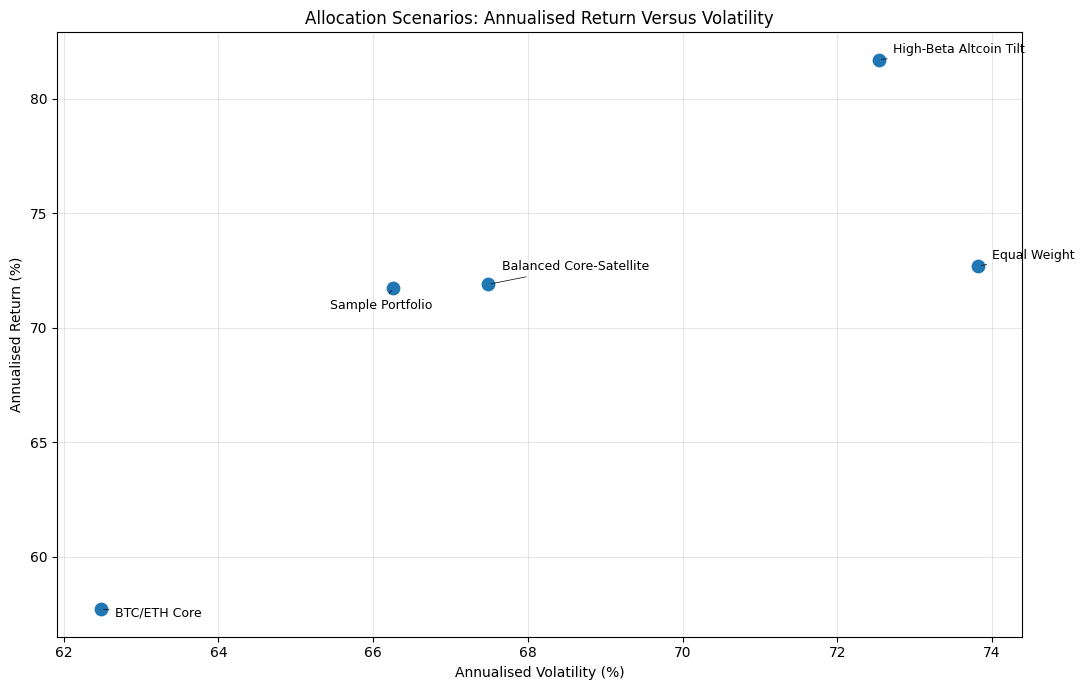

In [32]:
plt.figure(figsize=(11, 7))

plt.scatter(
    allocation_comparison["Annualised Volatility"] * 100,
    allocation_comparison["Annualised Return"] * 100,
    s=80
)

label_offsets = {
    "Sample Portfolio": (-45, -15),
    "Balanced Core-Satellite": (10, 10),
    "Equal Weight": (10, 5),
    "BTC/ETH Core": (10, -5),
    "High-Beta Altcoin Tilt": (10, 5)
}

for _, row in allocation_comparison.iterrows():
    allocation_name = row["Allocation"]
    x_value = row["Annualised Volatility"] * 100
    y_value = row["Annualised Return"] * 100

    x_offset, y_offset = label_offsets.get(allocation_name, (10, 10))

    plt.annotate(
        allocation_name,
        xy=(x_value, y_value),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=9,
        arrowprops=dict(arrowstyle="-", linewidth=0.5)
    )

plt.title("Allocation Scenarios: Annualised Return Versus Volatility")
plt.xlabel("Annualised Volatility (%)")
plt.ylabel("Annualised Return (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Allocation Scenario Findings

The allocation comparison shows that portfolio construction has a meaningful impact on both return and risk.

The high-beta altcoin tilt produced the highest historical return, but it also had the highest volatility and the deepest drawdown. This suggests that increasing exposure to higher-beta crypto assets can improve upside during favourable market periods, but materially increases downside risk.

The BTC/ETH core allocation produced lower returns, but also had lower volatility and a smaller maximum drawdown. This makes it a more defensive allocation relative to the higher-beta portfolios.

The sample portfolio and balanced core-satellite allocation sit between these two extremes. They provide more upside than the BTC/ETH core allocation, while avoiding some of the additional volatility and drawdown risk of the high-beta altcoin tilt.

Overall, the allocation comparison shows that the strongest historical return was not necessarily the most balanced portfolio. The preferred allocation depends on whether the investor prioritises maximum upside, lower drawdown, or a more balanced risk-return profile.

## Overall Portfolio Risk Findings

The dashboard shows that the sample crypto portfolio produced very strong historical returns, but these returns came with substantial risk.

The portfolio experienced high annualised volatility and a maximum drawdown of almost 80%, showing that the return path was highly unstable. This is visible in both the portfolio value chart and the drawdown chart.

At the asset level, SOL, XRP, LINK and ADA displayed particularly high standalone volatility and severe historical drawdowns. BTC had a lower risk contribution than its portfolio weight, while SOL contributed more risk than its weight alone would suggest.

The correlation analysis shows that all selected crypto assets were positively correlated. This means that diversification benefits were limited, particularly during broad market sell-offs.

The stress tests confirm this point. Portfolio losses were manageable under isolated asset-specific shocks, but much more severe when the whole crypto market was assumed to fall together.

Overall, the dashboard suggests that crypto portfolio risk is driven not only by individual asset volatility, but also by correlation, allocation size and market-wide downside scenarios.

## Limitations And Possible Improvements

This dashboard is a simplified historical risk analysis and has several limitations.

The analysis uses historical daily price data from `yfinance`, so results may vary depending on data quality, asset availability and future price updates. The sample also begins when all selected assets have available price data, which means earlier BTC and ETH history is excluded.

The dashboard assumes fixed portfolio weights and does not model rebalancing, taxes, trading fees, slippage or liquidity constraints. In practice, maintaining target weights would require periodic trading and would involve additional costs.

The stress tests are hypothetical scenarios rather than forecasts. They are useful for understanding possible downside exposure, but they do not predict future market behaviour.

The Sharpe ratio is included as a simple risk-adjusted return measure, but it has limitations when applied to crypto assets because crypto returns can be highly volatile, skewed and exposed to extreme tail events.

Future improvements could include portfolio rebalancing rules, rolling correlation analysis, rolling risk contribution, downside beta, Monte Carlo simulations, stablecoin or cash allocations, and live data integration.

## Project Summary

This project created a historical crypto portfolio risk dashboard using Python.

The dashboard analysed BTC, ETH, SOL, BNB, XRP, ADA and LINK using daily price data. It calculated portfolio performance, asset-level risk, drawdowns, rolling volatility, correlations, Value at Risk, Expected Shortfall, risk contribution, stress scenarios and allocation comparisons.

The main finding is that crypto portfolio returns can be highly attractive during favourable market periods, but portfolio risk remains heavily exposed to volatility, deep drawdowns and market-wide correlation during stress periods.

## Final Conclusion

This dashboard shows that a multi-asset crypto portfolio can produce very strong historical returns, but those returns come with significant volatility, deep drawdowns and high sensitivity to broad market stress.

The sample portfolio grew substantially over the historical sample period, but it also experienced a maximum drawdown of almost 80%. This means that even a profitable long-term allocation would have required the investor to tolerate severe temporary losses.

The analysis shows that risk is not distributed equally across the portfolio. BTC represented the largest allocation, but contributed less risk than its weight alone would suggest. SOL, by contrast, had a smaller allocation but contributed disproportionately to total portfolio risk because of its higher volatility.

The correlation analysis shows that crypto assets tend to move together. This limits diversification benefits, especially during broad market sell-offs. The stress testing section confirms that isolated asset shocks are less damaging than market-wide scenarios where BTC, ETH and altcoins fall together.

The allocation comparison shows that portfolio construction materially affects the risk-return profile. A high-beta altcoin tilt produced the strongest historical returns, but also carried the highest volatility and deepest drawdown. A BTC/ETH core allocation was more defensive, but sacrificed upside.

Overall, the dashboard demonstrates that crypto portfolio management should not focus only on return. A more complete assessment requires volatility, drawdown, correlation, Value at Risk, Expected Shortfall, risk contribution and stress testing.